In [6]:
import pandas as pd
df = pd.read_csv("Stuudent.csv", sep=";")

In [11]:
print("=== First 5 rows ===")
display(df.head())

=== First 5 rows ===


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72.0,72.0,74.0
1,female,group C,some college,standard,completed,69.0,90.0,88.0
2,female,group B,master's degree,standard,none,90.0,95.0,93.0
3,male,group A,associate's degree,free/reduced,none,47.0,57.0,NaN
4,male,group C,some college,standard,none,76.0,78.0,75.0


In [9]:
print("\n=== Columns and data types ===")
df.info()


=== Columns and data types ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1001 non-null   object 
 1   race/ethnicity               1002 non-null   object 
 2   parental level of education  1001 non-null   object 
 3   lunch                        1001 non-null   object 
 4   test preparation course      1002 non-null   object 
 5   math score                   1000 non-null   float64
 6   reading score                1000 non-null   float64
 7   writing score                999 non-null    float64
dtypes: float64(3), object(5)
memory usage: 62.8+ KB


In [ ]:
print("\n=== Descriptive statistics ===")
display(df.describe())


=== Descriptive statistics ===


,math score,reading score,writing score
count,1000.000000,1000.000000,999.000000
mean,66.131000,69.220000,68.162162
std,15.152869,14.560275,15.379688
min,0.000000,17.000000,10.000000
25%,57.000000,59.000000,58.000000
50%,66.000000,70.000000,69.000000
75%,77.000000,79.000000,79.000000
max,100.000000,100.000000,145.000000


In [ ]:
print("\n=== Column names ===")
print(df.columns)


=== Column names ===
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1002
Number of columns: 8


In [ ]:
# ----------------------------
# Step 2: Check Missing Values
# ----------------------------
print("=== Missing Values per Column ===")
print(df.isnull().sum())

=== Missing Values per Column ===
gender                         1
race/ethnicity                 0
parental level of education    1
lunch                          1
test preparation course        0
math score                     2
reading score                  2
writing score                  3
dtype: int64


In [ ]:
# Handle Missing Values without warnings
numeric_cols = ['math score','reading score','writing score']
categorical_cols = ['gender','parental level of education','lunch']

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')

print("=== Missing Values After Handling ===")
print(df.isnull().sum())

=== Missing Values After Handling ===
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [12]:
# ----------------------------
# Step 3: Remove Duplicates
# ----------------------------
print("Duplicate rows before removal:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicate rows after removal:", df.duplicated().sum())

Duplicate rows before removal: 2
Duplicate rows after removal: 0


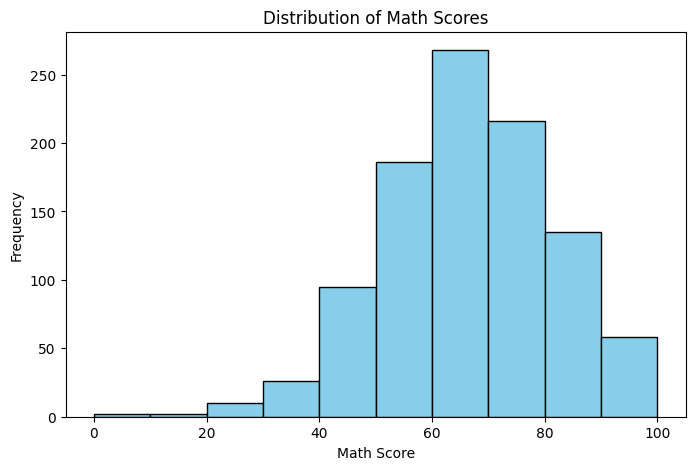

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df["math score"], bins=10, color='skyblue', edgecolor='black')
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")

plt.savefig("hist_math.png")
plt.show()

<Figure size 800x500 with 0 Axes>

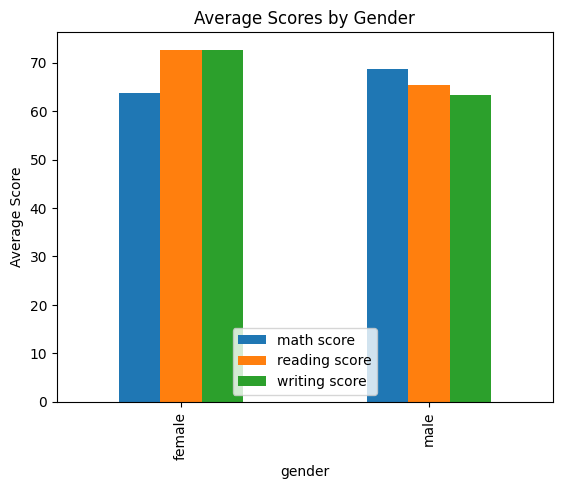

In [15]:
plt.figure(figsize=(8,5))
df.groupby("gender")[["math score","reading score","writing score"]].mean().plot(kind="bar")
plt.title("Average Scores by Gender")
plt.ylabel("Average Score")

plt.savefig("bar_gender.png")
plt.show()

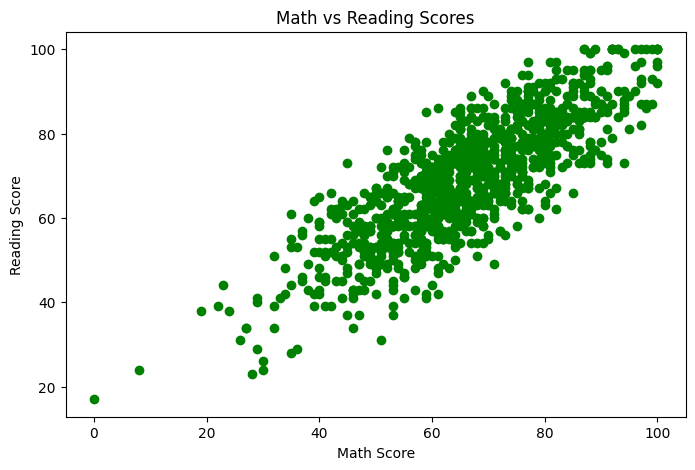

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(df["math score"], df["reading score"], color='green')
plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.title("Math vs Reading Scores")

plt.savefig("scatter_math_reading.png")
plt.show()

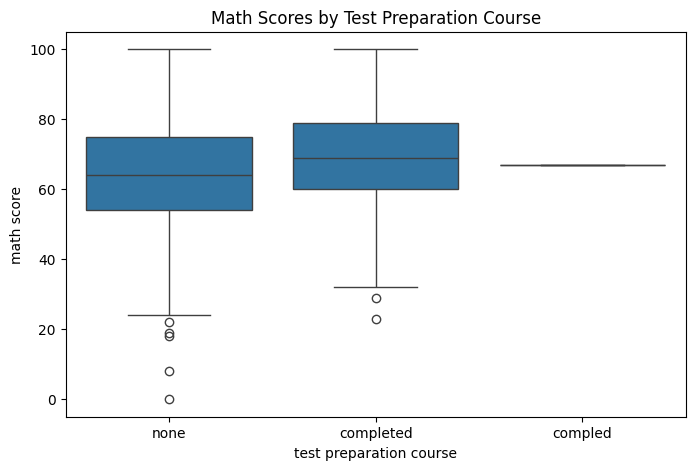

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x="test preparation course", y="math score", data=df)
plt.title("Math Scores by Test Preparation Course")

plt.savefig("boxplot_testprep.png")
plt.show()

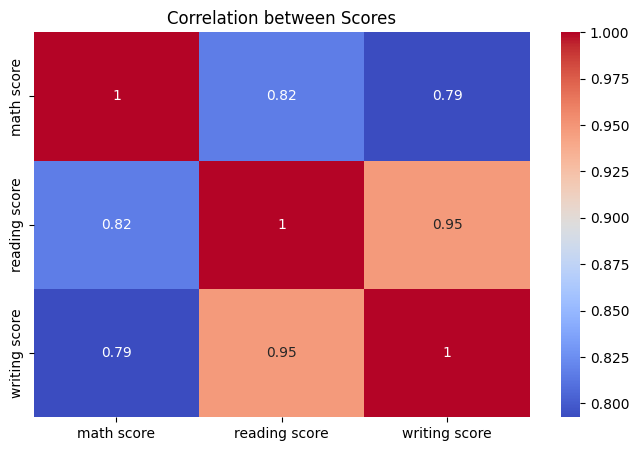

In [18]:
plt.figure(figsize=(8,5))
sns.heatmap(df[["math score","reading score","writing score"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation between Scores")

plt.savefig("heatmap_corr.png")
plt.show()

In [20]:
print("""
Patterns and Insights Summary:

Most students scored between 60 and 80 in all subjects.
There is a strong positive correlation between math, reading, and writing scores.
Female students performed better in reading and writing, while males performed slightly better in math.
Students who completed the test preparation course achieved higher scores on average.
Overall, academic performance across subjects is strongly related.
""")


Patterns and Insights Summary:

Most students scored between 60 and 80 in all subjects.
There is a strong positive correlation between math, reading, and writing scores.
Female students performed better in reading and writing, while males performed slightly better in math.
Students who completed the test preparation course achieved higher scores on average.
Overall, academic performance across subjects is strongly related.

